In [7]:
import pandas as pd

# Define where your real data file lives
file_path = r"C:\Users\abhis\Downloads\project 3\co2_emissions.csv"

# Load the file into a variable named 'df'
df = pd.read_csv(file_path)

print("✅ Success! Tools loaded and dataset imported.")
print(f"Initial Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns.")

✅ Success! Tools loaded and dataset imported.
Initial Dataset Size: 7385 rows and 12 columns.


In [8]:
# Display the first 5 rows of our data
df.head()

,make,model,vehicle_class,engine_size,cylinders,transmission,fuel_type,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
0,ACURA,ILX,COMPACT,2.0,4,AS,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS,Z,12.1,8.7,10.6,27,244


In [9]:
# Check for missing values and understand data types
print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Data Structure & Types ---")
print(df.info())

--- Missing Values Check ---
make                              0
model                             0
vehicle_class                     0
engine_size                       0
cylinders                         0
transmission                      0
fuel_type                         0
fuel_consumption_city             0
fuel_consumption_hwy              0
fuel_consumption_comb(l/100km)    0
fuel_consumption_comb(mpg)        0
co2_emissions                     0
dtype: int64

--- Data Structure & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   make                            7385 non-null   object 
 1   model                           7385 non-null   object 
 2   vehicle_class                   7385 non-null   object 
 3   engine_size                     7385 non-null   float64
 4   cylinders       

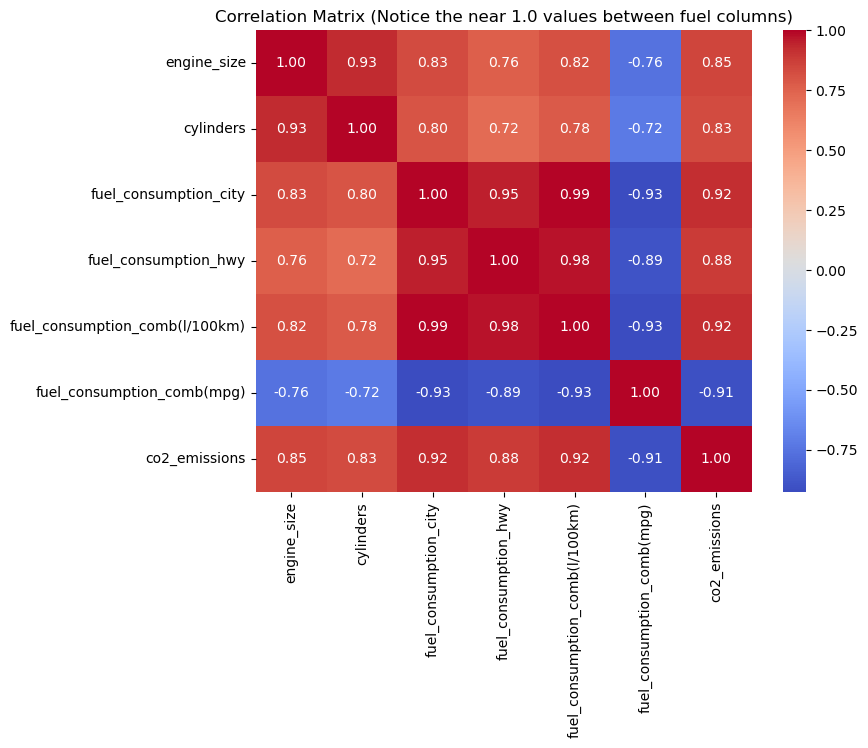


✅ Redundant fuel consumption metrics removed!
New dataset shape: 9 columns left.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize correlation BEFORE dropping to see the redundancy
plt.figure(figsize=(8, 6))
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Notice the near 1.0 values between fuel columns)')
plt.show()

# 2. Keep only the essential numerical columns to prevent multicollinearity
# We drop city, hwy, and mpg, keeping only the combined L/100km metric
df_cleaned = df.drop(columns=[
    'fuel_consumption_city', 
    'fuel_consumption_hwy', 
    'fuel_consumption_comb(mpg)'
])

print("\n✅ Redundant fuel consumption metrics removed!")
print(f"New dataset shape: {df_cleaned.shape[1]} columns left.")

In [11]:
print("--- Unique Values in Categorical Columns ---")
for col in ['fuel_type', 'transmission', 'vehicle_class']:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

--- Unique Values in Categorical Columns ---

Value counts for fuel_type:
fuel_type
X    3637
Z    3202
E     370
D     175
N       1
Name: count, dtype: int64

Value counts for transmission:
transmission
AS    3127
A     1851
M     1185
AM     646
AV     576
Name: count, dtype: int64

Value counts for vehicle_class:
vehicle_class
SUV - SMALL                 1217
MID-SIZE                    1133
COMPACT                     1022
SUV - STANDARD               735
FULL-SIZE                    639
SUBCOMPACT                   606
PICKUP TRUCK - STANDARD      538
TWO-SEATER                   460
MINICOMPACT                  326
STATION WAGON - SMALL        252
PICKUP TRUCK - SMALL         159
MINIVAN                       80
SPECIAL PURPOSE VEHICLE       77
VAN - PASSENGER               66
STATION WAGON - MID-SIZE      53
VAN - CARGO                   22
Name: count, dtype: int64


Removed 'N' fuel type. New shape: (7384, 12)


C:\Users\abhis\AppData\Local\Temp\ipykernel_4852\210185123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='fuel_type', y='co2_emissions', palette='Set2')


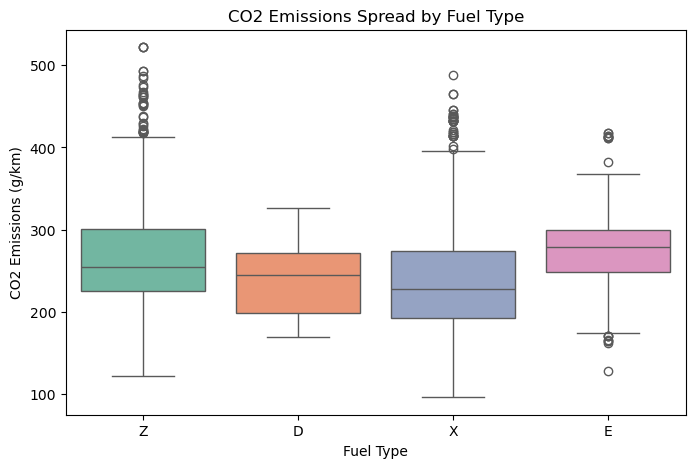

C:\Users\abhis\AppData\Local\Temp\ipykernel_4852\210185123.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='transmission', y='co2_emissions', palette='Pastel1')


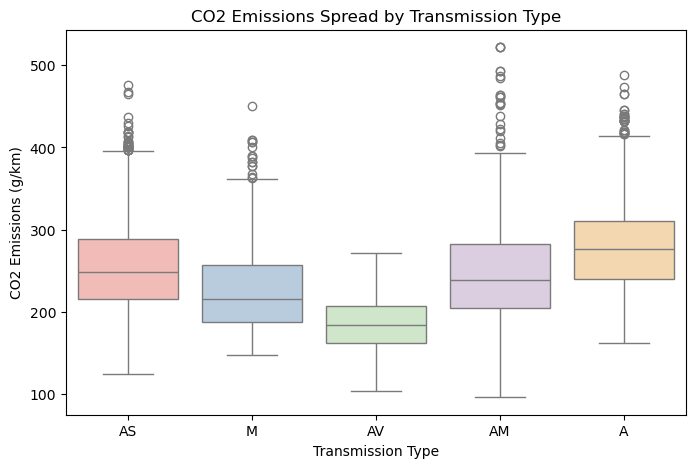

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Remove the single Natural Gas ('N') outlier row
df_filtered = df[df['fuel_type'] != 'N']
print(f"Removed 'N' fuel type. New shape: {df_filtered.shape}")

# 2. Visualize how Fuel Type impacts CO2 Emissions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filtered, x='fuel_type', y='co2_emissions', palette='Set2')
plt.title('CO2 Emissions Spread by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

# 3. Visualize how Transmission impacts CO2 Emissions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_filtered, x='transmission', y='co2_emissions', palette='Pastel1')
plt.title('CO2 Emissions Spread by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()

In [13]:
# Count how many rows are exact duplicates
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 1112


In [14]:
# Drop duplicate rows and save the clean data into a new variable called 'df_clean'
df_clean = df.drop_duplicates()

print("--- Data Cleaning Summary ---")
print(f"Original Dataset Size: {df.shape[0]} rows")
print(f"Cleaned Dataset Size:  {df_clean.shape[0]} rows")
print(f"Successfully Removed:  {df.shape[0] - df_clean.shape[0]} duplicate rows!")

--- Data Cleaning Summary ---
Original Dataset Size: 7385 rows
Cleaned Dataset Size:  6273 rows
Successfully Removed:  1112 duplicate rows!


In [15]:
# Generate descriptive statistics for our cleaned data
df_clean.describe()

,engine_size,cylinders,fuel_consumption_city,fuel_consumption_hwy,fuel_consumption_comb(l/100km),fuel_consumption_comb(mpg),co2_emissions
count,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000
mean,3.163000,5.620596,12.615591,9.073426,11.022111,27.395026,251.247250
std,1.365294,1.846424,3.550572,2.277893,2.945028,7.225472,59.235396
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.700000,10.300000,12.700000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


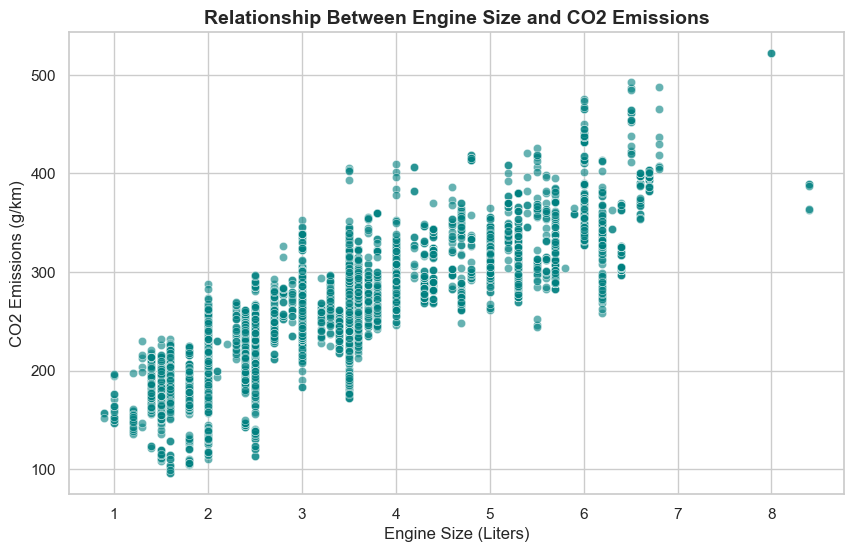

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of our plots
sns.set_theme(style="whitegrid")

# Create a scatter plot to view the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='co2_emissions', alpha=0.6, color='teal')

# Add titles and labels
plt.title('Relationship Between Engine Size and CO2 Emissions', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size (Liters)', fontsize=12)
plt.ylabel('CO2 Emissions (g/km)', fontsize=12)

# Display the plot
plt.show()

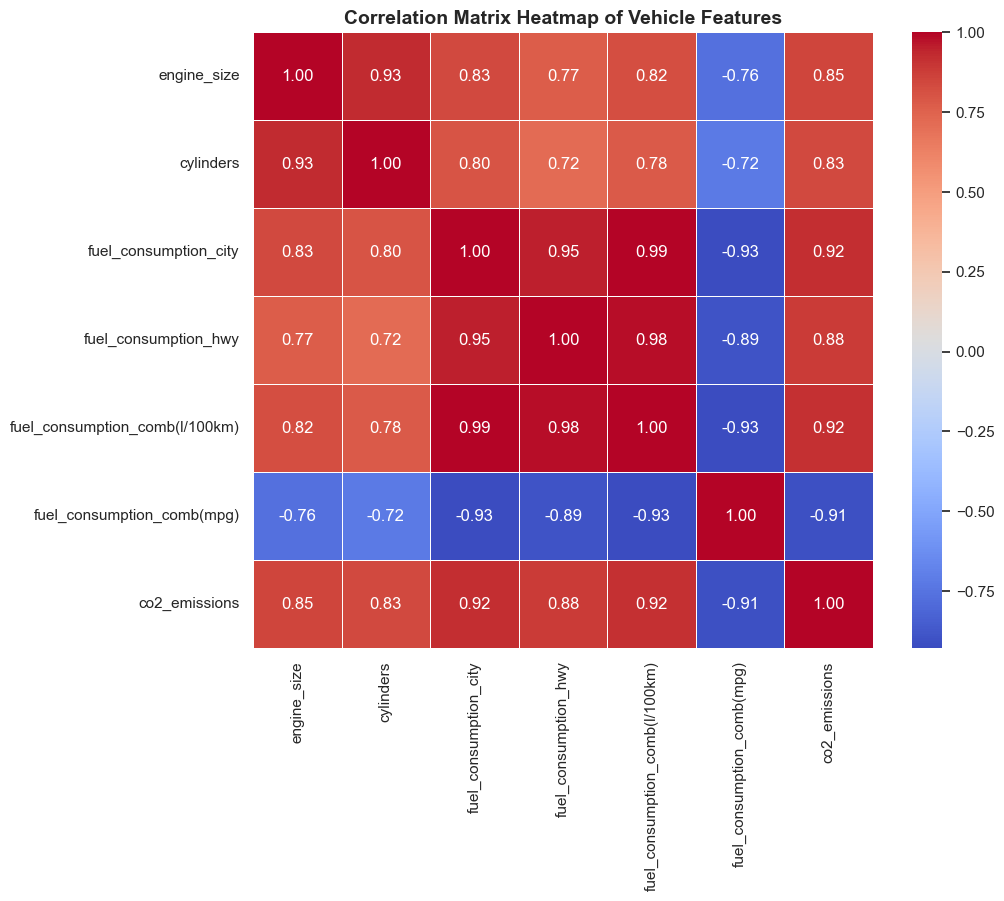

In [17]:
# 1. Filter out only the numerical columns from our clean data
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the Pearson correlation matrix
corr_matrix = numeric_cols.corr()

# 3. Create the heatmap plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title('Correlation Matrix Heatmap of Vehicle Features', fontsize=14, fontweight='bold')
plt.show()

In [18]:
# 1. Group the clean data by fuel type and look at the average CO2 emissions for each
fuel_analysis = df_clean.groupby('fuel_type')['co2_emissions'].agg(['count', 'mean']).reset_index()

print("--- CO2 Emissions Breakdown By Fuel Type ---")
print(fuel_analysis)

--- CO2 Emissions Breakdown By Fuel Type ---
  fuel_type  count        mean
0         D    147  235.238095
1         E    330  276.048485
2         N      1  213.000000
3         X   3030  236.118152
4         Z   2765  265.731284


In [19]:
# 1. Select the columns we want to use for predicting emissions
# We exclude 'make' and 'model' because they have hundreds of unique values
feature_cols = ['vehicle_class', 'engine_size', 'cylinders', 'transmission', 
                'fuel_type', 'fuel_consumption_city', 'fuel_consumption_hwy', 
                'fuel_consumption_comb(l/100km)', 'fuel_consumption_comb(mpg)']

# Extract our inputs (X) and our target output (y)
X = df_clean[feature_cols]
y = df_clean['co2_emissions']

# 2. Convert text columns into mathematical 1s and 0s automatically
X_encoded = pd.get_dummies(X, drop_first=True)

print("--- Preprocessing Complete ---")
print(f"Features matrix shape after encoding text columns: {X_encoded.shape}")

--- Preprocessing Complete ---
Features matrix shape after encoding text columns: (6273, 29)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Split the encoded data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 2. Initialize our machine learning model
model = LinearRegression()

# 3. Train the model on our training data
model.fit(X_train, y_train)

print("--- Model Training Complete ---")
print(f"Training features size: {X_train.shape[0]} vehicles")
print(f"Testing features size:  {X_test.shape[0]} vehicles")
print("✅ Linear Regression model trained successfully!")

--- Model Training Complete ---
Training features size: 5018 vehicles
Testing features size:  1255 vehicles
✅ Linear Regression model trained successfully!


In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Have the model predict CO2 emissions for the unseen testing data
y_pred = model.predict(X_test)

# 2. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"R-squared (R2) Score: {r2:.4f} (or {r2*100:.2f}%)")
print(f"Mean Absolute Error:   {mae:.2f} g/km")

--- Model Evaluation Metrics ---
R-squared (R2) Score: 0.9930 (or 99.30%)
Mean Absolute Error:   3.10 g/km


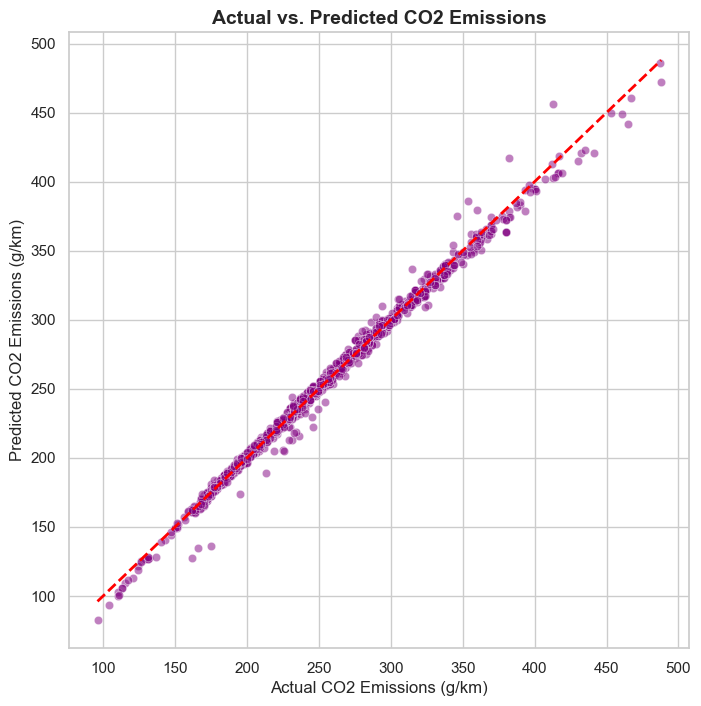

In [22]:
# Create a regression evaluation plot
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='purple')

# Plot the perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Actual vs. Predicted CO2 Emissions', fontsize=14, fontweight='bold')
plt.xlabel('Actual CO2 Emissions (g/km)', fontsize=12)
plt.ylabel('Predicted CO2 Emissions (g/km)', fontsize=12)
plt.show()

In [23]:
import pickle

# 1. Save the trained Linear Regression model to a file
with open('co2_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

# 2. Save the structure of your encoded columns
with open('model_columns.pkl', 'wb') as columns_file:
    pickle.dump(X_encoded.columns.tolist(), columns_file)

print("--- Deployment Export Complete ---")
print("✅ Saved 'co2_model.pkl' (The Brains)")
print("✅ Saved 'model_columns.pkl' (The Structure)")
print("Both files are ready to be picked up by Streamlit or Flask!")

--- Deployment Export Complete ---
✅ Saved 'co2_model.pkl' (The Brains)
✅ Saved 'model_columns.pkl' (The Structure)
Both files are ready to be picked up by Streamlit or Flask!


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pickle

# 1. Clean the dataset right before processing
# Remove the single 'N' row and drop the 3 redundant fuel consumption metrics
df_cleaned = df[df['fuel_type'] != 'N'].drop(columns=[
    'fuel_consumption_city', 
    'fuel_consumption_hwy', 
    'fuel_consumption_comb(mpg)'
])

# 2. Separate Features and Target
# 'make' and 'model' have too many unique values for a simple linear model, so we drop them
X = df_cleaned.drop(columns=['co2_emissions', 'make', 'model']) 
y = df_cleaned['co2_emissions']

# 3. One-Hot Encode your categorical variables
X_encoded = pd.get_dummies(X, columns=['vehicle_class', 'transmission', 'fuel_type'], drop_first=True)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Train the Optimized Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. OVERWRITE your deployment export files with the clean architecture
with open('co2_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

with open('model_columns.pkl', 'wb') as columns_file:
    pickle.dump(X_encoded.columns.tolist(), columns_file)

print("--- Deployment Export Updated successfully! ---")
print("✅ Cleaned 'co2_model.pkl' saved.")
print("✅ Streamlined 'model_columns.pkl' saved (Duplicate features removed!).")

--- Deployment Export Updated successfully! ---
✅ Cleaned 'co2_model.pkl' saved.
✅ Streamlined 'model_columns.pkl' saved (Duplicate features removed!).


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Final Model Evaluation ---")
print(f"Variance Explained (R² Score): {r2:.4f} ({r2*100:.2f}%)")
print(f"Average Prediction Error (MAE): {mae:.2f} g/km")

--- Final Model Evaluation ---
Variance Explained (R² Score): 0.9923 (99.23%)
Average Prediction Error (MAE): 3.02 g/km


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor


In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)

results_df.sort_values("R2 Score", ascending=False)

,Model,R2 Score,MAE,MSE,RMSE
4,XGBoost,0.997566,2.015444,8.462277,2.908999
2,Random Forest,0.996830,2.057113,11.020844,3.319766
1,Decision Tree,0.995759,2.009239,14.744664,3.839878
3,Gradient Boosting,0.995614,2.766743,15.246421,3.904667
0,Linear Regression,0.992321,3.021709,26.694356,5.166658


In [30]:
import joblib

joblib.dump(models["XGBoost"], "xgboost_co2_model.pkl")

print("Model saved successfully!")

Model saved successfully!


C:\Users\abhis\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


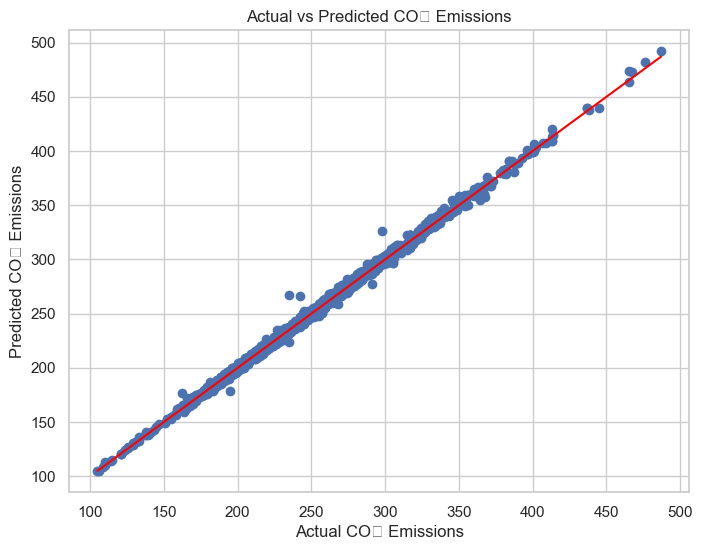

In [31]:
import matplotlib.pyplot as plt

y_pred = models["XGBoost"].predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions")
plt.show()

<Figure size 1000x600 with 0 Axes>

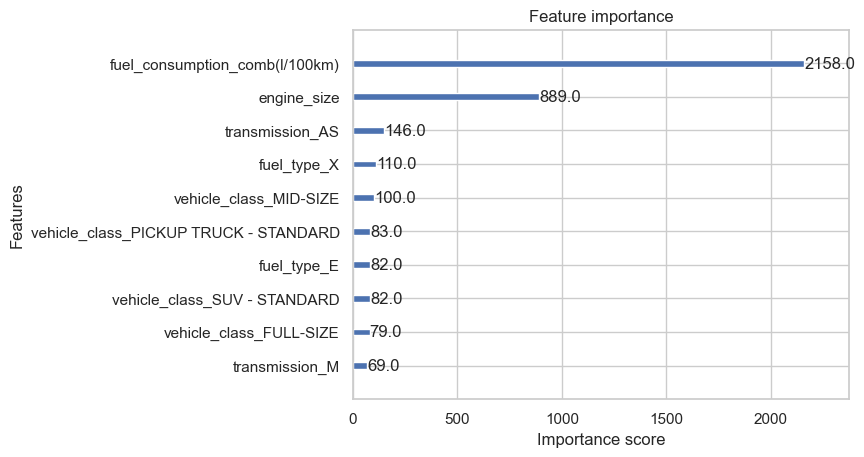

In [32]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_importance(models["XGBoost"], max_num_features=10)
plt.show()

In [33]:
sample = X_test.iloc[[0]]

prediction = models["XGBoost"].predict(sample)

print("Predicted CO₂ Emission:", prediction[0])
print("Actual CO₂ Emission:", y_test.iloc[0])


Predicted CO₂ Emission: 357.72278
Actual CO₂ Emission: 368


In [34]:
import joblib

joblib.dump(models["XGBoost"], "xgboost_co2_model.pkl")

print("✅ XGBoost model saved successfully!")

✅ XGBoost model saved successfully!


In [35]:
import os

print(os.path.exists("xgboost_co2_model.pkl"))

True


C:\Users\abhis\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


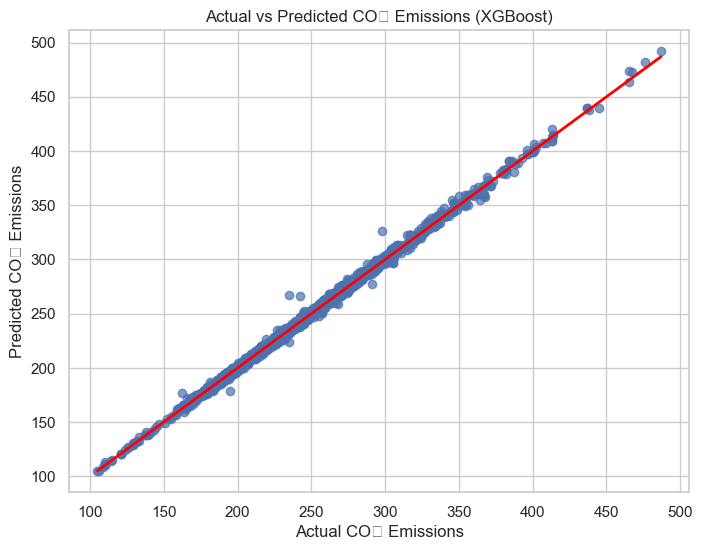

In [36]:
import matplotlib.pyplot as plt

# Predict using the best model
y_pred = models["XGBoost"].predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions (XGBoost)")
plt.grid(True)

plt.show()
